# Lesion Matrix Build

Prototipo passo-passo del costruttore della matrice lesionale (soggetti × voxel): cerca le maschere, fissa la griglia comune, ricampiona, binarizza, impila. **La versione di produzione è `src/pipeline/build_lesion_matrix.py`** (guida: `docs/guides/matrix_building.md`); questo notebook serve a vedere ogni passo con i propri occhi, non a produrre l'artefatto.

Contenuto:

1. caricamento delle maschere e validazione (una per soggetto)
2. allineamento sulla griglia comune e costruzione di `X`
3. sanity check sul valore dei voxel
4. riduzione ai soli voxel mai-costanti e visualizzazione della matrice 2D
5. frequenza voxel-wise (overlap lesionale della coorte)

La caratterizzazione delle maschere (volume, lateralità, fuori dal brain) e la scelta di chi escludere stanno in `notebooks/exploration/lesion_analysis.ipynb`.

In [1]:
import os
import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import numpy as np
import pandas as pd
from nilearn.image import resample_to_img
from nilearn.plotting import plot_stat_map


In [2]:
DATA_ROOT = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data/clinical_connectome/derivatives")
DATASETS = ["UNIPD/WashU", "UNIPD/PASPORT", "UNIPD/PSP", "UKLFR/stroke_UKLFR", "UCL-UK/UCLStrokeData"]
LESION_GLOB = "manual_masks/sub-*/anat/*_label-lesion_mask.nii.gz"

CACHE_DIR = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data/derived/lesion_matrix")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

## Lesions Loading

Cerca tutte le lesion mask MNI per i dataset in `DATASETS` sotto data/clinical_connectome, verificando che ogni cartella soggetto ne contenga esattamente una (nessun soggetto mancante o duplicato) e che i file trovati siano tutti .nii.gz. Stampa il conteggio per dataset e il totale.

In [3]:
lesion_files: dict[str, list[Path]] = {}

for dataset in DATASETS:
    # Trova le maschere usando il nuovo pattern BIDS
    files = sorted((DATA_ROOT / dataset).glob(LESION_GLOB))

    # Conta le cartelle dei soggetti sotto "manual_masks"
    manual_masks_dir = DATA_ROOT / dataset / "manual_masks"
    if not manual_masks_dir.exists():
        raise ValueError(f"Directory non trovata: {manual_masks_dir}")
        
    n_subject_dirs = len([p for p in manual_masks_dir.iterdir() if p.is_dir()])

    # Validazione ferrea (niente fallback silenziosi)
    if len(files) != n_subject_dirs:
        raise ValueError(
            f"{dataset}: {n_subject_dirs} subject dirs but only "
            f"{len(files)} lesion masks found — check the local data copy"
        )

    lesion_files[dataset] = files
    print(f"{dataset:25s} {len(files):4d} lesions")

total = sum(len(files) for files in lesion_files.values())
print(f"{'TOTAL':25s} {total:4d} lesions")


UNIPD/WashU                195 lesions
UNIPD/PASPORT               83 lesions
UNIPD/PSP                  168 lesions
UKLFR/stroke_UKLFR         705 lesions


UCL-UK/UCLStrokeData      4119 lesions
TOTAL                     5270 lesions


## Allineamento e Costruzione della Matrice 

Carica una lesione di riferimento (WashU) per fissare la griglia voxel comune:
- **91×109×91**: numero di voxel lungo i tre assi (x, y, z) della griglia, cioè la shape dell'array 3D.

- **@ 2mm**: dimensione di ciascun voxel lungo ogni asse.
- **MNI152NLin6Asym**: spazio standard in cui sono registrate.
Carica poi ogni lesion mask, la ricampiona sulla griglia comune quando la risoluzione nativa è diversa, la ribinarizza e la appiattisce in un vettore. Infine, impila tutti i vettori in una matrice `X` (soggetti × voxel) e costruisce i `metadata`.


In [4]:
reference_img = nib.load(lesion_files["UNIPD/WashU"][0])
print("reference grid:", reference_img.shape, reference_img.header.get_zooms())

reference grid: (182, 218, 182) (np.float32(1.0), np.float32(1.0), np.float32(1.0))


Carica ogni lesion mask, la ricampiona sulla griglia comune (91×109×91 @ 2mm) quando la risoluzione nativa è diversa, la ribinarizza e la appiattisce in un vettore. 

Impila tutti i vettori in una matrice X (n_soggetti × n_voxel) e costruisce metadata con soggetto e dataset di origine, mantenendo lo stesso ordine di riga per riga tra X e metadata.

In [22]:
subject_ids: list[str] = []
dataset_labels: list[str] = []
vectors: list[np.ndarray] = []

for dataset, files in lesion_files.items():
    for f in files:
        img = nib.load(f)
        # resample onto the common grid when resolution differs;
        # nearest-neighbor keeps the mask binary
        if img.shape != reference_img.shape:
            img = resample_to_img(
                img, reference_img, interpolation="nearest", force_resample=True, copy_header=True
            )
        # re-binarize: interpolation/registration can leave near-1/near-0 values
        data = img.get_fdata() > 0.5
        # flatten to a 1D vector and convert to uint8 for memory efficiency
        vectors.append(data.ravel().astype(np.uint8))
        subject_ids.append(f.name.split("_")[0])
        dataset_labels.append(dataset)

# stack the list of 1D vectors into a 2D matrix: shape (n_subjects, n_voxels)
X = np.stack(vectors)
# metadataframe has the same order as the rows of X
metadata = pd.DataFrame({"subject_id": subject_ids, "dataset": dataset_labels})
print("X shape:", X.shape)
metadata["dataset"].value_counts()

X shape: (5269, 902629)


dataset
UCL-UK/UCLStrokeData    4119
UKLFR/stroke_UKLFR       697
UNIPD/WashU              202
UNIPD/PSP                168
UNIPD/PASPORT             83
Name: count, dtype: int64

## Fast loading

Se abbiamo le matrici salvate in memoria, facciamo fast loading

In [6]:
print("Caricamento rapido dalla cache in corso...")

# La cartella di produzione già esistente
LOAD_DIR = CACHE_DIR / "21-07_s1.1-vol"

# 1. Carica le matrici pre-calcolate
X_reduced = np.load(LOAD_DIR / "matrix.npy") 
non_constant = np.load(LOAD_DIR / "non_constant_mask.npy")
metadata = pd.read_csv(LOAD_DIR / "metadata.csv")

# 2. Ricostruisci la X gigantesca originale
X = np.zeros((X_reduced.shape[0], len(non_constant)), dtype=np.uint8)
X[:, non_constant] = X_reduced

# 3. Troviamo dinamicamente la primissima maschera usando le TUE variabili
# (serve solo come reference_img per leggere il voxel_volume_mm3 in seguito)
prima_maschera = list((DATA_ROOT / DATASETS[0]).glob(LESION_GLOB))[0]
reference_img = nib.load(prima_maschera)

print(f"X ricostruita fedelmente alla shape originale: {X.shape}")
print(f"Maschera 1D (intero spazio 3D non ridotto). Shape: {non_constant.shape}")
print(f"Metadata caricati con successo. Shape: {metadata.shape}")


Caricamento rapido dalla cache in corso...


X ricostruita fedelmente alla shape originale: (1150, 902629)
Maschera 1D (intero spazio 3D non ridotto). Shape: (902629,)
Metadata caricati con successo. Shape: (1150, 2)


## Sanity Check

In [7]:
# 1. Controlli di base sui valori
unique_values = np.unique(X)
print(f"Valori unici nella matrice 2D ricostruita: {unique_values} (atteso: array([0, 1]))")

# Controllo NaN (se il dtype è intero, i NaN sono strutturalmente impossibili)
if X.dtype.kind == "f":
    print(f"NaN nella matrice: {int(np.isnan(X).sum())}")
else:
    print(f"Matrice dtype={X.dtype} (intero) -> NaN strutturalmente impossibile, controllo superato.")

# 2. Controllo dei pazienti a cui è "sparita" la lesione 
# (Cerchiamo pazienti in cui la somma dei voxel lesionali è esattamente 0)
zero_load_subjects = metadata.loc[X.sum(axis=1) == 0, "subject_id"].tolist()
print(f"\nSoggetti con volume lesionale a zero: {len(zero_load_subjects)}")
if zero_load_subjects:
    print(f"  -> {zero_load_subjects} (Attenzione: potresti volerli rimuovere!)")


Valori unici nella matrice 2D ricostruita: [0 1] (atteso: array([0, 1]))
Matrice dtype=uint8 (intero) -> NaN strutturalmente impossibile, controllo superato.



Soggetti con volume lesionale a zero: 0


## Riduzione (artefatto 2D)

Scartiamo i voxel che non sono mai stati lesionati in nessun paziente. È un'ottimizzazione essenziale per risparmiare memoria e calcolo: una colonna interamente a 0 non contribuisce ad alcuna distanza matematica nei successivi algoritmi di clustering. Infine, salviamo l'artefatto per i prossimi step.

In [8]:
# Mantiene solo i voxel lesionati in almeno un soggetto
# (solo ricalcolo in-memory per esplorazione: l'artefatto di produzione con
# questi stessi array e' gia' salvato da src/pipeline/build_lesion_matrix.py
# in data/derived/lesion_matrix/21-07_s1.1-vol/ - non lo si rigenera/sovrascrive
# da qui, si veda docs/guides/matrix_building.md per un run vero)
non_constant = X.any(axis=0)
X_reduced = X[:, non_constant]

print(f"Voxel totali originali: {X.shape[1]}")
print(f"Voxel non-costanti (utili): {X_reduced.shape[1]}")
print(f"Dimensione matrice: {X_reduced.shape}")


Voxel totali originali: 902629
Voxel non-costanti (utili): 254865
Dimensione matrice: (1150, 254865)


## Matrix visualization

In [9]:
# 1. Troviamo gli indici dei voxel più frequenti per assicurarci di vedere degli "1"
# (ordinati dal più lesionato al meno lesionato)
top_voxels = np.argsort(X_reduced.sum(axis=0))[::-1]

# 2. Creiamo una sottomatrice per la VISTA A TABELLA: 
# Primi 15 soggetti vs i 15 voxel più lesionati in assoluto
subset_X = X_reduced[:15, top_voxels[:15]]

# Convertiamo in DataFrame per visualizzarla bene
df_vista = pd.DataFrame(
    subset_X, 
    index=metadata['subject_id'].iloc[:15], # Usiamo gli ID veri dei pazienti
    columns=[f"Vox_{i}" for i in top_voxels[:15]]
)

print("Vista a tabella (Primi 15 soggetti x 15 voxel più frequenti):")
# Mostriamo la tabella evidenziando visivamente gli 1 (rosso) e sbiadendo gli 0 (grigio)
display(df_vista.style.map(lambda x: 'background-color: #ff9999; color: black; font-weight: bold' if x == 1 else 'color: #e0e0e0'))

# 3. Creiamo una sottomatrice per la VISTA GRAFICA (Heatmap):
# Primi 50 soggetti vs i primi 100 voxel più frequenti
patch_X = X_reduced[:50, top_voxels[:100]]

plt.figure(figsize=(15, 6))


Vista a tabella (Primi 15 soggetti x 15 voxel più frequenti):


,Vox_204746,Vox_204745,Vox_204804,Vox_204686,Vox_204687,Vox_204567,Vox_204508,Vox_204688,Vox_204744,Vox_204863,Vox_208738,Vox_204805,Vox_200403,Vox_204689,Vox_208680
subject_id,,,,,,,,,,,,,,,
sub-STUNIPD0001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0002,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0003,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
sub-STUNIPD0005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0008,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0009,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0011,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sub-STUNIPD0012,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

## Frequenza Voxel-wise

Frequenza voxel-wise calcolata su 254865 feature (voxel utili)
Voxel mai lesionati in nessun soggetto: 0 (atteso 0)
Voxel lesionati in tutti i soggetti: 0 (atteso 0)
Voxel lesionati in almeno il 10% della coorte (core dell'overlap): 3642
Voxel più frequentemente lesionato in assoluto: 180/1150 soggetti (15.7%)


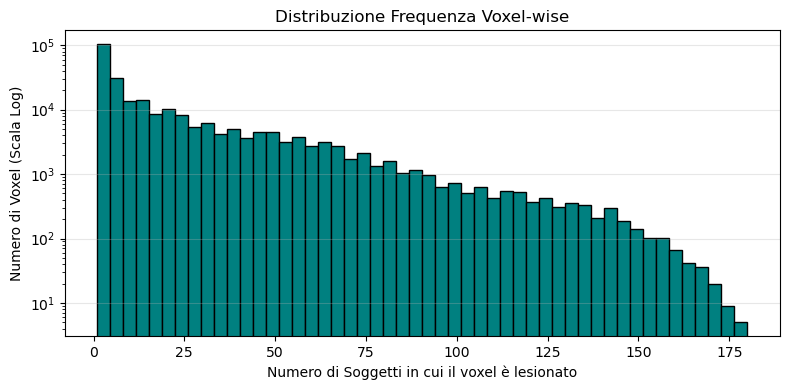

In [10]:
import matplotlib.pyplot as plt

# Calcola la somma lungo le colonne (quanti soggetti hanno un 1 in quel voxel specifico)
voxel_freqs = X_reduced.sum(axis=0)
n_subjects = X_reduced.shape[0]

print(f"Frequenza voxel-wise calcolata su {X_reduced.shape[1]} feature (voxel utili)")
print(f"Voxel mai lesionati in nessun soggetto: {(voxel_freqs == 0).sum()} (atteso 0)")
print(f"Voxel lesionati in tutti i soggetti: {(voxel_freqs == n_subjects).sum()} (atteso 0)")
print(f"Voxel lesionati in almeno il 10% della coorte (core dell'overlap): {(voxel_freqs >= 0.10 * n_subjects).sum()}")
print(f"Voxel più frequentemente lesionato in assoluto: {voxel_freqs.max()}/{n_subjects} soggetti ({(voxel_freqs.max()/n_subjects)*100:.1f}%)")

# Creazione del Plot
plt.figure(figsize=(8, 4))
plt.hist(voxel_freqs, bins=50, color='teal', edgecolor='black')
plt.title("Distribuzione Frequenza Voxel-wise")
plt.xlabel("Numero di Soggetti in cui il voxel è lesionato")
plt.ylabel("Numero di Voxel (Scala Log)")
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Analizziamo la distribuzione di quante volte ogni singolo voxel (feature) risulta lesionato all'interno dell'intera coorte. Questo controllo ci permette di quantificare l'overlap lesionale globale e confermare matematicamente che l'artefatto sia stato ripulito dai voxel inutili.
